In [41]:
import pandas as pd

## Step 1 : Split Column into X(feature) and y(label)

In [42]:
df = pd.read_csv('salary.csv')
X = df[['YearsExperience']]  # -> must be in Df that's why [[]] 
y = df['Salary']  # -> must be Series

## Step 2 : Split Data into Training and Test Set

In [43]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test  = train_test_split(X,y,test_size = 0.20, random_state =101)

## Step 3 : Fit Simple Linear Regression Model to Training Data

In [44]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[9440.46]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['YearsExperience']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.604e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


## Step 4 : Make Prediction

In [45]:
y_pred = model.predict(X_test)
print('Predeicted Values On Test Set :',y_pred)

Predeicted Values On Test Set : [ 90235.22172621 108172.10301013  56249.55192509  81738.80427593
  40200.76340789 116668.52046041]


## Step 5 : Visualize Training Set Result

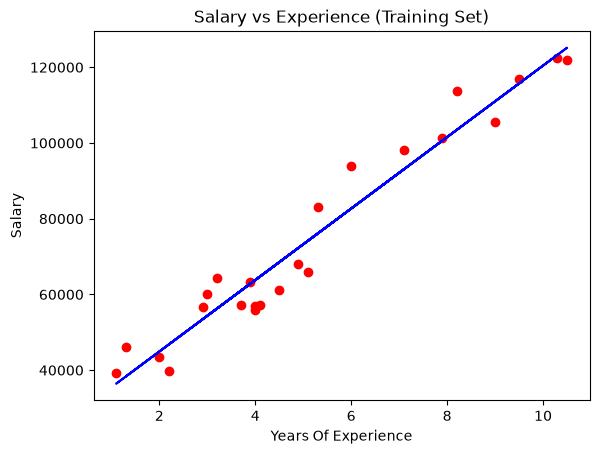

In [46]:
import matplotlib.pyplot as plt
plt.scatter(X_train,y_train,color='red')
plt.plot(X_train,model.predict(X_train),color='blue')
plt.title('Salary vs Experience (Training Set)')
plt.xlabel('Years Of Experience')
plt.ylabel('Salary')
plt.show()

## Step 6 : Visualize The Test Set Result

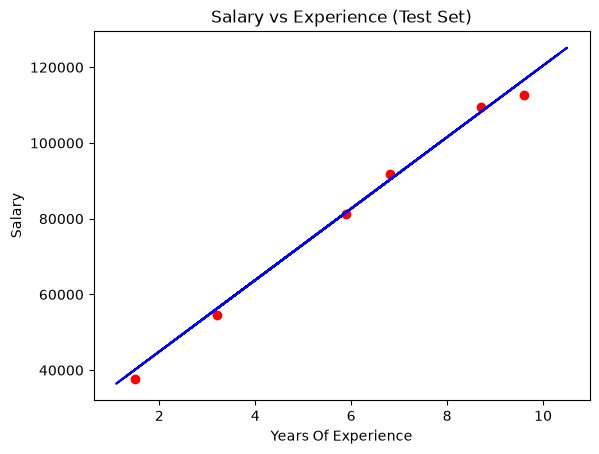

In [47]:
plt.scatter(X_test,y_test,color='red')
plt.plot(X_train,model.predict(X_train),color='blue')  # Same Regression Line
plt.title('Salary vs Experience (Test Set)')
plt.xlabel('Years Of Experience')
plt.ylabel('Salary')
plt.show()

## Setp 7 : Make New Prediction

In [48]:
new_X_values_df = pd.DataFrame({'YearsExperience':[1,3,5,8,12,15,20]})
new_y_pred = model.predict(new_X_values_df)
print('Predeiction For New Experience Values:',new_y_pred)

Predeiction For New Experience Values: [ 35480.53149107  54361.45915836  73242.38682565 101563.77832658
 139325.63366116 167647.0251621  214849.34433032]


## Step 8 : Model Evaluation

In [49]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

print('Model Evaluation Metrices')
print('Mean Absolute Error (MAE) :',mae)
print('Mean Squared Error (MSE) :',mse)
print('R2 Score :',r2)

Model Evaluation Metrices
Mean Absolute Error (MAE) : 1907.5525554956257
Mean Squared Error (MSE) : 4934969.878489006
R2 Score : 0.993422386435995


# Exercise

Exercise : Predict house price using Gr living area (housing.csv)

In [90]:
df = pd.read_csv('housing.csv')
df.head()

,Id,LotArea,OverallQual,YearBuilt,TotalBsmtSF,GrLivArea,FullBath,BedroomAbvGr,KitchenQual,TotRmsAbvGrd,GarageArea,SalePrice
0,1,8450,7,2003,856,1710,2,3,Gd,8,548,208500
1,2,9600,6,1976,1262,1262,2,3,TA,6,460,181500
2,3,11250,7,2001,920,1786,2,3,Gd,6,608,223500
3,4,9550,7,1915,756,1717,1,3,Gd,7,642,140000
4,5,14260,8,2000,1145,2198,2,4,Gd,9,836,250000


In [102]:
X = df[['GrLivArea','LotArea','TotRmsAbvGrd','TotalBsmtSF']]
y = df['SalePrice']

,GrLivArea,LotArea,TotRmsAbvGrd,TotalBsmtSF
0,1710,8450,8,856
1,1262,9600,6,1262
2,1786,11250,6,920
3,1717,9550,7,756
4,2198,14260,9,1145


In [114]:
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.80,random_state=42)

In [115]:
model = LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ 83.86, 0.23,-2194.72, 60.5 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['GrLivArea','LotArea','TotRmsAbvGrd','TotalBsmtSF']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1010
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [116]:
y_pred = model.predict(X_test)
print('Predicted Values For y_test :',y_pred)

Predicted Values For y_test : [143448.00782394 292523.21713196 139330.99996695 187103.29586556
 224731.65618116  85721.95336214 199266.39145172 160007.58268893
  85826.42164288 153500.57115263 165268.17746357 117915.46569425
 121124.37721371 208537.15136729 185162.50113798 135450.44650836
 182638.54963491 145686.05522926 135872.94294516 200084.97261615
 206337.46340752 169753.12166242 156097.42937811 128728.80088013
 196536.59902019 164975.79750833 183372.17925735 121450.18166999
 178723.45201626 186203.1152118  127264.76762719 217899.66874191
 334372.23659792 131650.57329933 222007.00950803 156188.21286005
 220087.98525645 198299.38331617 274748.70812644  69174.96302089
 137292.26350597 219831.79346003 129468.33476189 281216.4046777
 134997.89740301 232087.12231314 123523.01183945 127522.13915985
 278947.84406034 168987.29908889 125382.53868529 218552.49078022
 118179.08283524 320405.4757315  115689.45437666 238699.77236344
 181452.41023535 154054.94821994 145602.28405359  61076.43169

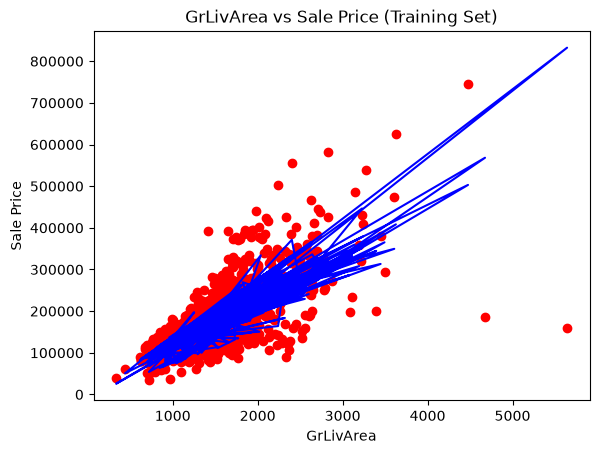

In [117]:
plt.scatter(X_train['GrLivArea'],y_train,color='red')
plt.plot(X_train['GrLivArea'],model.predict(X_train),color='blue')
plt.title('GrLivArea vs Sale Price (Training Set)')
plt.xlabel('GrLivArea')
plt.ylabel('Sale Price')
plt.show()

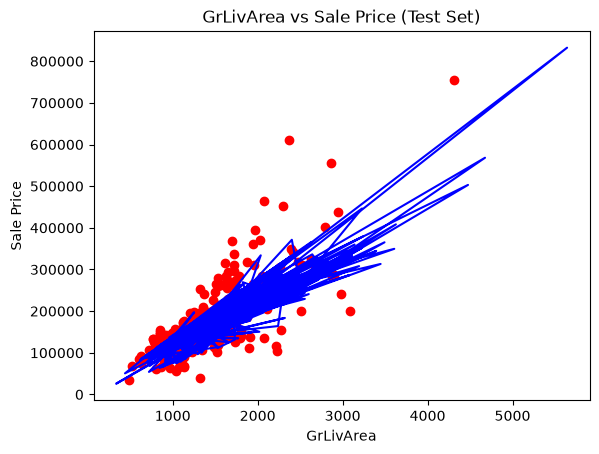

In [118]:
plt.scatter(X_test['GrLivArea'],y_test,color='red')
plt.plot(X_train['GrLivArea'],model.predict(X_train),color='blue')  # Same Regression Line
plt.title('GrLivArea vs Sale Price (Test Set)')
plt.xlabel('GrLivArea')
plt.ylabel('Sale Price')
plt.show()

In [120]:
# new_X = pd.DataFrame({'GrLivArea':[1250,1400,1500,1000,900]})
# new_y_pred = model.predict(new_X)
# print('Prediction For New X Values :',new_y_pred)

In [121]:
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

print('Model Evaluation Metrices')
print('Mean Absolute Error (MAE) :',mae)
print('Mean Squared Error (MSE) :',mse)
print('R2 Score :',r2)

Model Evaluation Metrices
Mean Absolute Error (MAE) : 32121.69961188437
Mean Squared Error (MSE) : 2465282825.5807915
R2 Score : 0.6785947873676075
